# NB3 

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import re

Let's import `jour_df` from the pickle `2023-03-21_NB2_jour_df_part3.pkl` and `papers_df` from the pickle `2023-03-21_NB2_papers_df_part4.pkl`

In [2]:
papers_df = pd.read_pickle('2023-03-28_NB2_papers_df_part4.pkl')
jour_df = pd.read_pickle('2023-03-21_NB2_jour_df_part3.pkl')

In [3]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,nature,journal,17.897,1276.0,United Kingdom,Western Europe
1,science,journal,14.589,1229.0,United States,Northern America
2,proceedings of the national academy of science...,journal,4.184,805.0,United States,Northern America
3,chemical reviews,journal,18.718,745.0,United States,Northern America
4,physical review letters,journal,3.246,647.0,United States,Northern America


In [4]:
papers_df.head(5)

,first_auth,second_auth,third_auth,Cites,Title,Year,Source,Type,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,query_author
0,d shi,valerio adinolfi,r comin,4186,low trapstate density and long carrier diffusi...,2015,science,Journal article,523.0000,523.0,8,0,edward sargent
1,k lin,j xing,ln quan,2319,perovskite lightemitting diodes with external ...,2018,nature,Journal article,463.7500,258.0,9,0,edward sargent
2,sa mcdonald,g konstantatos,s zhang,2163,solutionprocessed pbs quantum dot infrared pho...,2005,nature materials,Journal article,120.1875,309.0,7,0,edward sargent
3,h tan,a jain,oleksandr voznyy,1951,efficient and stable solutionprocessed planar ...,2017,science,Journal article,325.2500,279.0,7,0,edward sargent
4,g konstantatos,ia howard,a fischer,1897,ultrasensitive solutioncast quantum dot photod...,2006,nature,Journal article,111.5625,271.0,7,0,edward sargent


Let's attempt to merge `papers_df` with `jour_df` on the publication titles. We will use a left join in order to preserve the columns in the `papers_df` that weren't able to join to `jour_df` for investigation. We will call the joined data frame `join_df`.

In [5]:
def get_merge_per():
    global papers_df, jour_df, entry_goal

    join_df = pd.merge(left = papers_df, right = jour_df, left_on = 'Source', right_on = 'Title', how = 'left')

    non_nulls_per = (1 - join_df['Title_y'].isna().sum()/join_df['Title_y'].isna().count())
    entries_left = (join_df['Title_y'].isna() == False).sum()
    diff = entry_goal - entries_left
    
    print("{:.2%} of the entries merged!".format(non_nulls_per))
    print(f'{round(diff)} rows left to go!')
    return join_df

In [6]:
entry_goal = papers_df.shape[0]*0.95
print('The number of entries to aim for is', round(entry_goal))

The number of entries to aim for is 16652


In [7]:
join_df = get_merge_per()

86.46% of the entries merged!
1498 rows left to go!


Luckily, almost 80% of the entries so we're starting off strong! Let's investigate the values in `Source` that didn't merge with `Title` to see where we could make some formatting adjustments to merge more rows. Note, the cell below was executed multiple times to take in a different sample of 10 values to get an idea of the title variations, so the title variations discussed below it may differ from what would be initially outputted in the cell.

In [8]:
# I executed this line multiple times to get an idea of some of the title variations
join_df['Source'][join_df['Title_y'].isna()].sample(10).value_counts()

chemistrya european journal                                2
journal of physics d applied physics                       1
bulletin of the russian academy of sciences physics  ss    1
adv mater                                                  1
physica status solidi b                                    1
annales de chimiescience des matriaux                      1
fizika tverdogo tela                                       1
lithuanian physics journal                                 1
j mater sci mater electron                                 1
Name: Source, dtype: int64

One pattern that was noticed was that there would often been variations of publications, notably `science` and `science advances` that were followed by a code, usually beginning with `ea`. Let's look at the distribution of those variables specifically.

In [9]:
join_df['Source'][join_df['Source'].str.contains(r'^science', regex = True)].value_counts()

science                                          77
science advances                                 14
science china chemistry                          14
science bulletin                                  8
science of advanced materials                     7
science and technology of advanced materials      5
science china materials                           5
science advances  eabq                            4
science advances  eabb                            4
science advances  eabc                            3
science advances  eabf                            3
science advances  eabj                            3
science advances  eaay                            3
science advances  eabg                            2
science advances  eabd                            2
science advances  eaat                            2
science advances  eaao                            2
science advances  eaau                            2
science advances  eaav                            2
science adva

Let's pull up the titles of a paper that has a suffix `eabq`

In [10]:
papers_df['Title'][papers_df['Source'] == 'science advances  eabq'].values[0]

'momentummatching and bandalignment van der waals heterostructures for highefficiency infrared photodetection'

From that paper's [citation](https://scholar.google.com/scholar?hl=en&as_sdt=0%2C5&q=Momentum-matching+and+band-alignment+van+der+W&btnG=#d=gs_cit&t=1679502207047&u=%2Fscholar%3Fq%3Dinfo%3AH-GM87rXWl0J%3Ascholar.google.com%2F%26output%3Dcite%26scirp%3D0%26hl%3Den) it appears that the `eabq` was accidentally pulled from the page number and appended to the title. The page number beginning with `ea` seems to be a consistent trend across both papers published in `science` and `science advances` so let's reformat those names so that those suffixes no longer exist. We will store the results in `test_df` to inspect before overwriting `papers_df`, and consequently, `jour_df`.

In [11]:
def remove_pattern(val, pattern, method = 'no_space'):
    
    assert isinstance(val, str), 'Input value must be a string'
    assert isinstance(pattern, str), 'Input pattern must be a string'
    
    if method == 'no_space':
        return re.sub(pattern, '', val).strip()
    elif method == 'one_space':
        return re.sub(pattern, ' ', val).strip()

In [12]:
test_df = join_df.assign(Source = join_df['Source'].apply(remove_pattern, pattern = r'\s*ea..$', method = 'no_space'))
test_df['Source'][test_df['Source'].str.contains(r'^science', regex = True)].value_counts()

science                                          83
science advances                                 57
science china chemistry                          14
science bulletin                                  8
science of advanced materials                     7
science and technology of advanced materials      5
science china materials                           5
science  aac                                      1
science bulletin s                                1
science  aad                                      1
science and technology                            1
science of the total environment                  1
science china physics mechanics and astronomy     1
science robotics                                  1
Name: Source, dtype: int64

It look like our method worked! We can apply the same technique to remove the `s` suffix from `science bulletin s` since that looks to just be appended on accident. But first, let's investigate the origins of the `aad` and `aac` suffixes.

In [13]:
print('Here is a paper title:')
papers_df['Title'][papers_df['Source'] == 'science  aac'].values[0]

Here is a paper title:


'building devices from colloidal quantum dots'

Like before, based on the paper's [citation](https://scholar.google.com/scholar?hl=en&as_sdt=0%2C5&q=%27Building+devices+from+colloidal+quantum+dots%27&btnG=#d=gs_cit&t=1679503521305&u=%2Fscholar%3Fq%3Dinfo%3AiNGwANcHelAJ%3Ascholar.google.com%2F%26output%3Dcite%26scirp%3D0%26hl%3Den) it appears that the `aad` and `aac` suffixes were incorrectly appended from the page numbers. Let's fix the formatting to remove those suffixes along with `s`.

In [14]:
# Creating a list of all the patterns to apply
pattern_list = [r'\s*ea..$', r'\s*aa.$', r'\ss$']

test_df = join_df.copy()
for i in pattern_list:
    test_df = test_df.assign(Source = test_df['Source'].apply(remove_pattern, pattern = i, method = 'no_space'))

test_df['Source'][test_df['Source'].str.contains(r'^science', regex = True)].value_counts()

science                                          85
science advances                                 57
science china chemistry                          14
science bulletin                                  9
science of advanced materials                     7
science and technology of advanced materials      5
science china materials                           5
science and technology                            1
science of the total environment                  1
science china physics mechanics and astronomy     1
science robotics                                  1
Name: Source, dtype: int64

The formatting was successful! Let's apply it to `papers_df` and re-join the data frames.

In [15]:
# Creating a list of all the patterns to apply
pattern_list = [r'\s*ea..$', r'\s*aa.$', r'\ss$']

for i in pattern_list:
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(remove_pattern, pattern = i, method = 'no_space'))

In [16]:
join_df = get_merge_per()

86.80% of the entries merged!
1437 rows left to go!


The number of entires that merged only went up by about 0.2%. Let's investigate the values with the most entires that did not join.

In [17]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

bulletin of the american physical society    80
journal of materials chemistry               71
chemistrya european journal                  67
physica status solidi a                      63
journal of physics d applied physics         61
angewandte chemie                            53
journal of nanoscience and nanotechnology    52
applied physics a                            43
physica status solidi b                      39
physical reviewsection bcondensed matter     29
Name: Source, dtype: int64

The most common values is `bulletin of the american physical society`. Let's see if there are any values in the `jour_df` that are similar.

In [18]:
jour_df['Title'][jour_df['Title'].str.contains('physical society')]

462     journal of the physical society of japan
2001      journal of the korean physical society
Name: Title, dtype: object

There were no values in `jour_df` that matched. Further investigation into this value reveled that the Bulletin of the American Physical Society is [a collection of conference proceedings](https://www.aps.org/meetings/baps/index.cfm). In general, we want to avoid including conference proceedings since their metrics are not tracked as often as conference papers, journal articles and books. Therefore, let's remove entires from `papers_df` from conference proceedings.

In [19]:
papers_df = papers_df.drop(papers_df[papers_df['Source'] == 'bulletin of the american physical society'].index)

In [20]:
join_df = get_merge_per()

87.20% of the entries merged!
1437 rows left to go!


From this analysis, we see that `conference` and `proceedings` are the two most frequently occurring words, followed by `th` which appears to be `the` mis-spelled, `international`, which could refer to the conference being an international meeting, and `ieee`, which is an acronym for Institute of Electrical and Electronics Engineers. There are also instances of other organization acronyms, like `mrs` for the Materials Research Society, and `aip` for the American Institute of Physics.

Let's search for values in `jour_df` that contain those organization acronyms and compare those to the values in `papers_df` to discern how to reformat the data.

In [21]:
def replace_word(val, match_word, out_word):
    match_check = all(i in val for i in match_word)
    if match_check:
        return out_word
    else:
        return val

This seems to work well, we were able to reduce around 12 unique titles in total. Let's apply the same method to `papers_df`.

In [22]:
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['ieee',  'photovoltaic', 'specialist'], out_word = 'conference record of the ieee photovoltaic specialists conference'))

In [23]:
join_df = get_merge_per()

87.20% of the entries merged!
1437 rows left to go!


---

In [24]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

journal of materials chemistry                     71
chemistrya european journal                        67
physica status solidi a                            63
journal of physics d applied physics               61
angewandte chemie                                  53
journal of nanoscience and nanotechnology          52
applied physics a                                  43
physica status solidi b                            39
physical reviewsection bcondensed matter           29
physica status solidi rrlrapid research letters    25
Name: Source, dtype: int64

In [25]:
jour_df['Title'][jour_df['Title'].str.contains('journal of materials chemistry')]

104    journal of materials chemistry a
405    journal of materials chemistry c
692    journal of materials chemistry b
Name: Title, dtype: object

In [26]:
import re

def edit_title(row):
    '''
    
    This function takes publication titles and uses regex to edit the format of that value.
    
    '''
    title = row
    
    assert isinstance(title, str), 'Input parameter must be a string'
    
    # Encode the titles in ASCII 
    title = title.encode('ascii', 'ignore').decode('ascii')
    
    # Get rid of 'The'
    title = re.sub(r'^The\s', '', title)
    
    # Get rid of '(discontinued)'
    title = re.sub(r'\(discontinued\)', '', title)
    
    # Insert spaces in '&word' case
    title = re.sub(r'\&\+?', 'and ', title)
    
    # Get rid of special characters 
    title = re.sub(r'[!@#$%\^\*\(\)-:\.=,\+\_]', '', title)
    
    # Get rid of double spacing
    title = re.sub(r'  ', ' ', title)
    
    return title.strip().lower()

In [27]:
title = 'journal of materials chemistry'
type_ = 'journal'
SJR = 2.41
H_index = int(314)
country = 'United Kingdom'
region = 'Western Europe'

jour_df.loc[jour_df.index.max() + 1, :] = [title, type_, SJR, H_index, country, region]

In [28]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

87.61% of the entries merged!
1366 rows left to go!


---

In [29]:
jour_df['Title'][jour_df['Title'].str.contains('journal of physics')]

112                   journal of physics condensed matter
242                                new journal of physics
351     journal of physics a mathematical and theoretical
611     journal of physics b atomic molecular and opti...
704            journal of physics and chemistry of solids
755     journal of physics g nuclear and particle physics
848                           american journal of physics
1042                 journal of physics conference series
1704                          canadian journal of physics
1777                           pramana journal of physics
1891                          european journal of physics
2008                         brazilian journal of physics
2207                           chinese journal of physics
2740                            indian journal of physics
2857                          romanian journal of physics
3162                           turkish journal of physics
4254                    journal of physics communications
4357          

In [30]:
print(jour_df[jour_df['Title'].str.contains('journal of physics')].loc[611, 'Title'])

journal of physics b atomic molecular and optical physics


In [31]:
null_df = join_df[join_df['Title_y'].isna()]

In [32]:
null_df['Source'][null_df['Source'].str.contains('journal of physics')].value_counts()

journal of physics d applied physics                    61
journal of physics materials                             8
journal of physics energy                                5
journal of physics condensed matter  r                   2
journal of physics f metal physics                       2
lithuanian journal of physics and technical sciences     2
journal of physics c solid state physics  l              2
journal of physics condensed matter  l                   1
armenian journal of physics                              1
journal of physics d applied physics  lt                 1
journal of physics photonics                             1
Name: Source, dtype: int64

In [33]:
test_df = null_df.copy()
test_df = test_df.assign(Source = test_df['Source'].apply(replace_word, match_word = ['journal of physics d'], out_word = 'journal of physics b atomic molecular and optical physics'))
test_df['Source'][test_df['Source'].str.contains('journal of physics')].value_counts()

journal of physics b atomic molecular and optical physics    62
journal of physics materials                                  8
journal of physics energy                                     5
journal of physics condensed matter  r                        2
journal of physics f metal physics                            2
lithuanian journal of physics and technical sciences          2
journal of physics c solid state physics  l                   2
journal of physics condensed matter  l                        1
armenian journal of physics                                   1
journal of physics photonics                                  1
Name: Source, dtype: int64

In [34]:
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['journal of physics d'], out_word = 'journal of physics b atomic molecular and optical physics'))

In [35]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

87.96% of the entries merged!
1304 rows left to go!


---

In [36]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

chemistrya european journal                                                  67
physica status solidi a                                                      63
angewandte chemie                                                            53
journal of nanoscience and nanotechnology                                    52
applied physics a                                                            43
physica status solidi b                                                      39
physical reviewsection bcondensed matter                                     29
physica status solidi rrlrapid research letters                              25
journal of vacuum science and technology b microelectronics and nanometer    23
optics express  aa                                                           19
Name: Source, dtype: int64

In [37]:
jour_df['Title'][jour_df['Title'].str.contains('european journal')]

65               european journal of operational research
85                           chemistry a european journal
256               european journal of medicinal chemistry
321                 european journal of organic chemistry
447               european journal of inorganic chemistry
841      european journal of lipid science and technology
927                 european journal of mechanics asolids
1285                european journal of mechanics bfluids
1441                          european journal of control
1524           european journal of wood and wood products
1891                          european journal of physics
1914                european journal of wildlife research
2084            european journal of engineering education
2148                european journal of mass spectrometry
2626                   european journal of remote sensing
2655    european journal of environmental and civil en...
3164           european journal of industrial engineering
3197      cent

In [38]:
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['chemistrya european journal'], out_word = 'chemistry a european journal'))

In [39]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

88.35% of the entries merged!
1237 rows left to go!


---

In [40]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

physica status solidi a                                                      63
angewandte chemie                                                            53
journal of nanoscience and nanotechnology                                    52
applied physics a                                                            43
physica status solidi b                                                      39
physical reviewsection bcondensed matter                                     29
physica status solidi rrlrapid research letters                              25
journal of vacuum science and technology b microelectronics and nanometer    23
optics express  aa                                                           19
inorganic chemistry communications                                           16
Name: Source, dtype: int64

In [41]:
jour_df['Title'][jour_df['Title'].str.contains('physica status')].values

array(['physica status solidi b basic research',
       'physica status solidi a applications and materials science',
       'physica status solidi rapid research letters'], dtype=object)

In [42]:
null_df['Source'][null_df['Source'].str.contains('physica status')].value_counts()

physica status solidi a                            63
physica status solidi b                            39
physica status solidi rrlrapid research letters    25
physica status solidi c                            12
physica status solidiaapplied research              6
physica status solidibbasic research                3
physica status solidi c s ss                        1
physica status solidirrl doi pssr                   1
physica status solidi a  rr                         1
Name: Source, dtype: int64

In [43]:
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['physica status solidi a'], out_word = 'physica status solidi a applications and materials science'))
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['physica status solidi b'], out_word = 'physica status solidi b basic research'))
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['physica status solidi', 'letters'], out_word = 'physica status solidi rapid research letters'))

In [44]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

89.08% of the entries merged!
1109 rows left to go!


---

In [45]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

angewandte chemie                                                            53
journal of nanoscience and nanotechnology                                    52
applied physics a                                                            43
physical reviewsection bcondensed matter                                     29
journal of vacuum science and technology b microelectronics and nanometer    23
optics express  aa                                                           19
inorganic chemistry communications                                           16
materials science and engineering b                                          14
verhandlungen der deutschen physikalischen gesellschaft                      12
physica status solidi c                                                      12
Name: Source, dtype: int64

In [46]:
title = 'journal of nanoscience and nanotechnology'
type_ = 'journal'
SJR = 0.235
H_index = int(108)
country = 'United States'
region = 'Northern America'

jour_df.loc[jour_df.index.max() + 1, :] = [title, type_, SJR, H_index, country, region]

In [47]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

89.38% of the entries merged!
1057 rows left to go!


---

In [48]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

angewandte chemie                                                            53
applied physics a                                                            43
physical reviewsection bcondensed matter                                     29
journal of vacuum science and technology b microelectronics and nanometer    23
optics express  aa                                                           19
inorganic chemistry communications                                           16
materials science and engineering b                                          14
verhandlungen der deutschen physikalischen gesellschaft                      12
physica status solidi c                                                      12
physica c superconductivity                                                  11
Name: Source, dtype: int64

In [49]:
jour_df['Title'][jour_df['Title'].str.contains('angewandte')].values

array(['angewandte chemie international edition',
       'zeitschrift fur angewandte mathematik und physik',
       'zamm zeitschrift fur angewandte mathematik und mechanik',
       'agit journal fur angewandte geoinformatik'], dtype=object)

In [50]:
null_df['Source'][null_df['Source'].str.contains('angewandte')].value_counts()

angewandte chemie                  53
angewandte chemiegerman edition     1
Name: Source, dtype: int64

In [51]:
papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = ['angewandte'], out_word = 'angewandte chemie international edition'))

In [52]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

89.69% of the entries merged!
1003 rows left to go!


---

In [53]:
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

applied physics a                                                            43
physical reviewsection bcondensed matter                                     29
journal of vacuum science and technology b microelectronics and nanometer    23
optics express  aa                                                           19
inorganic chemistry communications                                           16
materials science and engineering b                                          14
verhandlungen der deutschen physikalischen gesellschaft                      12
physica status solidi c                                                      12
boletn de la sociedad espaola de cermica y vidrio                            11
physica c superconductivity                                                  11
Name: Source, dtype: int64

In [54]:
jour_df['Title'][jour_df['Title'].str.contains('applied physics')].values

array(['applied physics letters', 'journal of applied physics',
       'journal physics d applied physics',
       'applied physics a materials science and processing',
       'japanese journal of applied physics',
       'applied physics b lasers and optics', 'applied physics express',
       'current applied physics', 'applied physics reviews',
       'epj applied physics',
       'indian journal of pure and applied physics',
       'johns hopkins apl technical digest applied physics laboratory',
       'journal of theoretical and applied physics', 'applied physics'],
      dtype=object)

In [55]:
null_df['Source'][null_df['Source'].str.contains('applied physics')].value_counts()

applied physics a                             43
applied physics b                              6
european physical journalapplied physics       5
japanese journal of applied physics r          5
japanese journal of applied physics s kb       2
applied physics a ss                           2
japanese journal of applied physics s bf       2
japanese journal of applied physics s fb       1
japanese journal of applied physics s cc       1
japanese journal of applied physics s nc       1
journal of applied physics  m                  1
japanese journal of applied physics se         1
japanese journal of applied physics s nb       1
japanese journal of applied physics s rf       1
japanese journal of applied physics s g        1
japanese journal of applied physics s fv       1
int j of advanced applied physics research     1
european physical journal applied physics      1
journal of applied physics  c                  1
current applied physics  ss                    1
japanese journal of 

In [56]:
match_words = [['japanese journal of applied physics'],
              ['current applied physics'],
              ['applied physics a'],
                ['applied physics b'],
               ['european physical journalapplied physics']]

out_words = ['japanese journal of applied physics',
             'current applied physics',
             'applied physics a materials science and processing',
             'applied physics b lasers and optics',
             'epj applied physics']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [57]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

90.12% of the entries merged!
927 rows left to go!


---

In [58]:
print('--- Here are the Top Sources ---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources ---


physical reviewsection bcondensed matter                                     29
journal of vacuum science and technology b microelectronics and nanometer    23
optics express  aa                                                           19
inorganic chemistry communications                                           16
materials science and engineering b                                          14
verhandlungen der deutschen physikalischen gesellschaft                      12
physica status solidi c                                                      12
advanced photonics research                                                  11
boletn de la sociedad espaola de cermica y vidrio                            11
physica c superconductivity                                                  11
Name: Source, dtype: int64

In [59]:
print('---Looking for matches in jour_df---')
jour_df['Title'][jour_df['Title'].str.contains('physical review')].values

---Looking for matches in jour_df---


array(['physical review letters', 'physical review b',
       'physical review d', 'physical review e', 'physical review a',
       'physical review c', 'physical review x',
       'physical review applied', 'physical review materials',
       'physical review fluids',
       'physical review physics education research',
       'physical review accelerators and beams'], dtype=object)

In [60]:
null_df['Source'][null_df['Source'].str.contains('physical review')].value_counts()

physical reviewsection bcondensed matter                    29
physical reviewsection bcondensed matter  r                  7
physical review b  r                                         5
physical review b condensed matter and materials physics     4
physical review b  l                                         4
physical review research                                     4
physical review e  r                                         1
physical review lettersusa                                   1
physical review b condensed matter;usa                       1
physical review b inljourev                                  1
physical review applied  l                                   1
physical review materials  l                                 1
Name: Source, dtype: int64

In [61]:
match_words = [['physical reviewsection bcondensed'],
              ['physical review b'],
              ['physical review applied'],
              ['physical review materials'],
              ['physical review letter']]

out_words = ['physical review b',
             'physical review b',
            'physical review applied',
            'physical review materials',
            'physical review letters']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [62]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

90.43% of the entries merged!
873 rows left to go!


---

In [63]:
print('--- Here are the Top Sources ---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources ---


journal of vacuum science and technology b microelectronics and nanometer    23
optics express  aa                                                           19
inorganic chemistry communications                                           16
materials science and engineering b                                          14
physica status solidi c                                                      12
verhandlungen der deutschen physikalischen gesellschaft                      12
boletn de la sociedad espaola de cermica y vidrio                            11
physica c superconductivity                                                  11
advanced photonics research                                                  11
applied catalysis                                                            10
Name: Source, dtype: int64

In [64]:
print('---Looking for matches in jour_df---')
jour_df['Title'][jour_df['Title'].str.contains('vacuum science')].values

---Looking for matches in jour_df---


array(['journal of vacuum science and technology bnanotechnology and microelectronics',
       'journal of vacuum science and technology a vacuum surfaces and films',
       'zhenkong kexue yu jishu xuebaojournal of vacuum science and technology'],
      dtype=object)

In [65]:
null_df['Source'][null_df['Source'].str.contains('vacuum science')].value_counts()

journal of vacuum science and technology b microelectronics and nanometer    23
journal of vacuum science and technology b nanotechnology and                 7
journal of vacuum science and technologysection b                             2
journal of vacuum science and technologysection bmicroelectronics             2
journal of vacuum science and technologysection a                             1
journal of vacuum science and technology a                                    1
Name: Source, dtype: int64

In [66]:
match_words = [['journal of vacuum science and technology b'],
              ['journal of vacuum science and technologysection b'],
              ['journal of vacuum science and technologysection a'],
              ['journal of vacuum science and technology a']]

out_words = ['journal of vacuum science and technology bnanotechnology and microelectronics',
             'journal of vacuum science and technology bnanotechnology and microelectronics',
             'journal of vacuum science and technology a vacuum surfaces and films',
             'journal of vacuum science and technology a vacuum surfaces and films']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [67]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

90.64% of the entries merged!
837 rows left to go!


---

In [68]:
print('--- Here are the Top Sources ---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources ---


optics express  aa                                         19
inorganic chemistry communications                         16
materials science and engineering b                        14
verhandlungen der deutschen physikalischen gesellschaft    12
physica status solidi c                                    12
physica c superconductivity                                11
advanced photonics research                                11
boletn de la sociedad espaola de cermica y vidrio          11
applied catalysis                                          10
communications materials                                   10
Name: Source, dtype: int64

In [69]:
obj = 'optics'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "optics"---


array(['optics express', 'optics letters', 'applied optics',
       'journal of the optical society of america a optics and image science and vision',
       'journal of biomedical optics', 'optics communications',
       'applied physics b lasers and optics',
       'optics and lasers in engineering',
       'journal of optics united kingdom', 'biomedical optics express',
       'journal of modern optics', 'optics and laser technology',
       'advances in optics and photonics',
       'progress in biomedical optics and imaging proceedings of spie',
       'optics and photonics news',
       'optics and spectroscopy english translation of optika i spektroskopiya',
       'guangxue jingmi gongchengoptics and precision engineering',
       'chinese optics letters', 'computer optics',
       'fiber and integrated optics',
       'conference proceedings lasers and electrooptics society annual meetingleos',
       'chinese optics',
       'optical memory and neural networks information opt

In [70]:
null_df['Source'][null_df['Source'].str.contains('optics')].value_counts()

optics express  aa                                             19
journal of optics                                               6
optics and spectroscopy                                         4
journal of optics a pure and applied optics                     4
advanced materials for optics and electronics                   2
nonlinear optics and applications xii                           2
optics for solar energy rmc                                     2
optics for solar energy sta                                     2
frontiers in optics fwc                                         2
optikinternational journal for light and electron optics        1
optics for solar energy sowc                                    1
biomedical optics btud                                          1
frontiers in optics jwa                                         1
nonlinear optics ntua                                           1
frontiers in optics ffb                                         1
frontiers 

In [71]:
match_words = [['optics express'],
              ['conference on lasers and electrooptics cleo'],
              ['journal of optics']]

out_words = ['optics express',
             'conference proceedings lasers and electrooptics society annual meetingleos',
             'journal of optics united kingdom']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [72]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

90.81% of the entries merged!
808 rows left to go!


---

In [73]:
print('--- Here are the Top Sources ---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources ---


inorganic chemistry communications                         16
materials science and engineering b                        14
verhandlungen der deutschen physikalischen gesellschaft    12
physica status solidi c                                    12
boletn de la sociedad espaola de cermica y vidrio          11
physica c superconductivity                                11
advanced photonics research                                11
journal of the electrochemical society  h                  10
applied catalysis                                          10
communications materials                                   10
Name: Source, dtype: int64

In [74]:
obj = 'materials science and'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "materials science and"---


array(['materials science and engineering a structural materials properties microstructure and processing',
       'applied physics a materials science and processing',
       'materials science and engineering r reports',
       'materials science and engineering c',
       'materials science and engineering b solidstate materials for advanced technology',
       'materials science and technology',
       'modelling and simulation in materials science and engineering',
       'journal of materials science and technology',
       'acs biomaterials science and engineering',
       'advances in materials science and engineering',
       'iop conference series materials science and engineering',
       'archives of materials science and engineering',
       'iranian journal of materials science and engineering',
       'gaofenzi cailiao kexue yu gongchengpolymeric materials science and engineering',
       'fenmo yejin cailiao kexue yu gongchengmaterials science and engineering of powder 

In [75]:
obj = 'materials science and'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "materials science and"---


materials science and engineering b               14
materials science and engineering a                4
materials science and condensed matter physics     2
journal of materials science and engineering a     1
Name: Source, dtype: int64

In [76]:
match_words = [['materials science and engineering a'],
              ['materials science and engineering b']]

out_words = ['materials science and engineering a structural materials properties microstructure and processing',
             'materials science and engineering b solidstate materials for advanced technology']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [77]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

90.92% of the entries merged!
789 rows left to go!


---

In [78]:
print('--- Here are the Top Sources ---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources ---


inorganic chemistry communications                         16
physica status solidi c                                    12
verhandlungen der deutschen physikalischen gesellschaft    12
boletn de la sociedad espaola de cermica y vidrio          11
physica c superconductivity                                11
advanced photonics research                                11
communications materials                                   10
applied catalysis                                          10
journal of polymer science part a polymer chemistry        10
journal of the electrochemical society  h                  10
Name: Source, dtype: int64

In [79]:
obj = 'physica c'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "physica c"---


array(['physica c superconductivity and its applications'], dtype=object)

In [80]:
obj = 'physica c'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "physica c"---


physica c superconductivity                11
physica c                                   1
physica c superconductivity;netherlands     1
Name: Source, dtype: int64

In [81]:
match_words = [['physica c']]

out_words = ['physica c superconductivity and its applications']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [82]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

90.99% of the entries merged!
776 rows left to go!


---

In [83]:
print('--- Here are the Top Sources ---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources ---


inorganic chemistry communications                         16
physica status solidi c                                    12
verhandlungen der deutschen physikalischen gesellschaft    12
advanced photonics research                                11
boletn de la sociedad espaola de cermica y vidrio          11
applied catalysis                                          10
journal of polymer science part a polymer chemistry        10
infomat                                                    10
journal of the electrochemical society  h                  10
communications materials                                   10
Name: Source, dtype: int64

In [84]:
obj = 'inorganic chemistry'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "inorganic chemistry"---


array(['inorganic chemistry', 'european journal of inorganic chemistry',
       'journal of biological inorganic chemistry',
       'inorganic chemistry communication',
       'inorganic chemistry frontiers', 'advances in inorganic chemistry',
       'comments on inorganic chemistry',
       'bioinorganic chemistry and applications',
       'russian journal of inorganic chemistry',
       'chinese journal of inorganic chemistry',
       'reviews in inorganic chemistry'], dtype=object)

In [85]:
obj = 'inorganic chemistry'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "inorganic chemistry"---


inorganic chemistry communications           16
open inorganic chemistry journal              1
inorganic chemistry communications volume     1
Name: Source, dtype: int64

In [86]:
match_words = [['inorganic chemistry communication']]

out_words = ['inorganic chemistry communication']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [87]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

91.09% of the entries merged!
759 rows left to go!


---

In [88]:
print('--- Here are the Top Sources That were Un-merged---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources That were Un-merged---


verhandlungen der deutschen physikalischen gesellschaft    12
physica status solidi c                                    12
advanced photonics research                                11
boletn de la sociedad espaola de cermica y vidrio          11
journal of the electrochemical society  h                  10
communications materials                                   10
journal of polymer science part a polymer chemistry        10
infomat                                                    10
applied catalysis                                          10
journal of the korean magnetics society                     9
Name: Source, dtype: int64

In [89]:
obj = 'solidi'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "solidi"---


array(['physica status solidi b basic research',
       'physica status solidi a applications and materials science',
       'physica status solidi rapid research letters'], dtype=object)

[Physica Status Solidi (C)](https://onlinelibrary.wiley.com/journal/16101642a) is in the [online data base](https://www.scimagojr.com/journalsearch.php?q=4700152710&tip=sid&clean=0) but not `jour_df`. Need to add the entry manually

In [90]:
title = edit_title('Physica Status Solidi (C) Current Topics in Solid State Physics')
type_ = 'journal'
SJR = 0.21
H_index = int(49)
country = 'Germany'
region = 'Western Europe'

jour_df.loc[jour_df.index.max() + 1, :] = [title, type_, SJR, H_index, country, region]

In [91]:
obj = 'solidi'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "solidi"---


array(['physica status solidi b basic research',
       'physica status solidi a applications and materials science',
       'physica status solidi rapid research letters',
       'physica status solidi c current topics in solid state physics'],
      dtype=object)

In [92]:
obj = 'solidi c'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "solidi c"---


physica status solidi c         12
physica status solidi c s ss     1
Name: Source, dtype: int64

In [93]:
match_words = [['solidi c']]

out_words = ['physica status solidi c current topics in solid state physics']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [94]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

91.16% of the entries merged!
746 rows left to go!


---

In [95]:
print('--- Here are the Top Sources That were Un-merged---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources That were Un-merged---


verhandlungen der deutschen physikalischen gesellschaft    12
advanced photonics research                                11
boletn de la sociedad espaola de cermica y vidrio          11
journal of polymer science part a polymer chemistry        10
infomat                                                    10
applied catalysis                                          10
journal of the electrochemical society  h                  10
communications materials                                   10
chemistryan asian journal                                   9
acta crystallographica afoundation and advances cc          9
Name: Source, dtype: int64

---

In [96]:
obj = 'applied catalysis'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "applied catalysis"---


array(['applied catalysis b environmental', 'applied catalysis a general'],
      dtype=object)

In [97]:
obj = 'applied catalysis'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "applied catalysis"---


applied catalysis      10
applied catalysis b     1
Name: Source, dtype: int64

In [98]:
print('Investigating the paper:')
papers_df['Title'][papers_df['Source'] == 'applied catalysis'].values[0]

Investigating the paper:


'effect of steam on the coking of platinum catalysts i inhibiting effect of steam at low partial pressure for the dehydrogenation of cyclopentane and the coking reaction'

[Applied Catalysis](https://www.sciencedirect.com/journal/applied-catalysis) is a journal that discontinued in 1991. It does not have a record in the online database, so we will drop those entries form `papers_df`.

In [99]:
drop_index = papers_df[papers_df['Source'] == 'applied catalysis'].index
papers_df = papers_df.drop(drop_index)

In [100]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

91.21% of the entries merged!
746 rows left to go!


Now we'll apply the correct formatting on the remaining values that have `applied catalysis` in the title.

In [101]:
obj = 'applied catalysis'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "applied catalysis"---


applied catalysis b    1
Name: Source, dtype: int64

In [102]:
match_words = [['applied catalysis a'],
              ['applied catalysis ageneral'],
              ['applied catalysis b']]

out_words = ['applied catalysis a general', 'applied catalysis a general', 'applied catalysis b environmental']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [103]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

91.22% of the entries merged!
745 rows left to go!


---

In [104]:
print('--- Here are the Top Sources That were Un-merged---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources That were Un-merged---


verhandlungen der deutschen physikalischen gesellschaft    12
boletn de la sociedad espaola de cermica y vidrio          11
advanced photonics research                                11
communications materials                                   10
journal of polymer science part a polymer chemistry        10
infomat                                                    10
journal of the electrochemical society  h                  10
journal of applied crystallography                          9
international journal of modern physics b n                 9
journal of the korean magnetics society                     9
Name: Source, dtype: int64

In [105]:
obj = 'acta crystallographica'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "acta crystallographica"---


array(['acta crystallographica section a foundations and advances',
       'acta crystallographica section fstructural biology communications',
       'acta crystallographica section b structural science crystal engineering and materials',
       'acta crystallographica section c structural chemistry',
       'acta crystallographica section e crystallographic communications'],
      dtype=object)

In [106]:
obj = 'acta crystallographica'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "acta crystallographica"---


acta crystallographica afoundation and advances cc                         9
acta crystallographica section b structural science crystal engineering    4
acta crystallographica afoundation and advances ss                         4
acta crystallographica section e structure reports online  oo              4
acta crystallographica section b structural science                        3
acta crystallographica                                                     2
acta crystallographica afoundation and advances e                          2
acta crystallographica afoundation and advances                            1
acta crystallographica section c crystal structure communications          1
Name: Source, dtype: int64

In [107]:
match_words = [['acta crystallographica afoundation'],
              ['acta crystallographica section b'],
              ['acta crystallographica section c'],
              ['acta crystallographica section e']]

out_words = ['acta crystallographica section a foundations and advances', 
             'acta crystallographica section b structural science crystal engineering and materials', 
             'acta crystallographica section c structural chemistry',
            'acta crystallographica section e crystallographic communications']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [108]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

91.38% of the entries merged!
717 rows left to go!


---

In [109]:
print('--- Here are the Top Sources That were Un-merged---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources That were Un-merged---


verhandlungen der deutschen physikalischen gesellschaft    12
advanced photonics research                                11
boletn de la sociedad espaola de cermica y vidrio          11
journal of the electrochemical society  h                  10
infomat                                                    10
communications materials                                   10
journal of polymer science part a polymer chemistry        10
journal of applied crystallography                          9
international journal of modern physics b n                 9
journal of the korean magnetics society                     9
Name: Source, dtype: int64

In [110]:
obj = 'electrochemical'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "electrochemical"---


array(['journal of the electrochemical society',
       'international journal of electrochemical science',
       'electrochemical society interface',
       'journal of new materials for electrochemical systems',
       'electrochemical energy reviews',
       'journal of electrochemical energy conversion and storage',
       'journal of electrochemical science and technology',
       'journal of electrochemical science and engineering'], dtype=object)

In [111]:
obj = 'electrochemical'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "electrochemical"---


journal of the electrochemical society  h        10
journal of the electrochemical society  a         5
journal of the electrochemical society  f         5
journal of the electrochemical society  c         4
journal of the electrochemical society  d         3
journal of the electrochemical society  g         2
electrochemical and solidstate letters  g         2
electrochemical and solidstate letters  j         1
electrochemical and solidstate letters  h         1
electrochemical and solid state letters  h        1
journal of the korean electrochemical society     1
journal of the electrochemical society  cc        1
journal of the electrochemical society  xx        1
journal of the electrochemical society  b         1
electrochemical and solidstate letters  b         1
international journal electrochemical science     1
Name: Source, dtype: int64

In [112]:
match_words = [['journal of the electrochemical society']]

out_words = ['journal of the electrochemical society']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [113]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

91.56% of the entries merged!
685 rows left to go!


---

In [114]:
print('--- Here are the Top Sources That were Un-merged---')
join_df['Source'][join_df['Title_y'].isna()].value_counts().head(10)

--- Here are the Top Sources That were Un-merged---


verhandlungen der deutschen physikalischen gesellschaft    12
advanced photonics research                                11
boletn de la sociedad espaola de cermica y vidrio          11
communications materials                                   10
journal of polymer science part a polymer chemistry        10
infomat                                                    10
journal of the korean magnetics society                     9
journal of applied crystallography                          9
international journal of modern physics b n                 9
chemistryan asian journal                                   9
Name: Source, dtype: int64

In [115]:
obj = 'journal of modern physics'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "journal of modern physics"---


array(['international journal of modern physics a',
       'international journal of modern physics d',
       'international journal of modern physics b',
       'international journal of modern physics c',
       'international journal of modern physics e'], dtype=object)

In [116]:
obj = 'journal of modern physics'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "journal of modern physics"---


international journal of modern physics b n    9
journal of modern physics                      2
Name: Source, dtype: int64

In [117]:
match_words = [['journal of modern physics b']]

out_words = ['international journal of modern physics b']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [118]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

91.62% of the entries merged!
676 rows left to go!


---

---

In [119]:
print('--- Here are the Top Sources That were Merged---')
join_df['Source'].value_counts().head(10)

--- Here are the Top Sources That were Merged---


journal of physical chemistry c             589
applied physics letters                     522
advanced materials                          474
physical review b                           467
acs applied materials and interfaces        424
journal of physical chemistry letters       352
advanced functional materials               342
chemistry of materials                      320
journal of the american chemical society    317
journal of applied physics                  315
Name: Source, dtype: int64

In [120]:
obj = 'physical chemistry'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "physical chemistry"---


journal of physical chemistry                                          7
journal of physical chemistry bcondensed phase                         4
physical chemistry of semiconductor materials and interfaces xviii     3
physical chemistry of semiconductor materials and interfaces xx        2
physical chemistry of interfaces and nanomaterials xv                  1
physical chemistry of semiconductor materials and interfaces xvi       1
physical chemistry of interfaces and nanomaterials xiii                1
current physical chemistry                                             1
physical chemistry of interfaces and nanomaterials iv                  1
physical chemistry of semiconductor materials and interfaces xxi pc    1
journal of physical chemistry letters  invited perspective             1
journal of physical chemistry b prof kankan bhattacharyya              1
physical chemistry of semiconductor materials and interfaces xvii      1
physical chemistry of semiconductor materials and i

In [121]:
obj = 'physical chemistry'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "physical chemistry"---


array(['journal of physical chemistry b',
       'journal of physical chemistry c',
       'physical chemistry chemical physics',
       'journal of physical chemistry a',
       'journal of physical chemistry letters',
       'annual review of physical chemistry', 'biophysical chemistry',
       'international reviews in physical chemistry',
       'russian journal of physical chemistry a',
       'protection of metals and physical chemistry of surfaces',
       'russian journal of physical chemistry b',
       'doklady physical chemistry', 'advances in physical chemistry',
       'physical chemistry research'], dtype=object)

In [122]:
match_words = [['journal of physical chemistry b'], ['journal of physical chemistry letters']]

out_words = ['journal of physical chemistry b', 'journal of physical chemistry letters']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [123]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

91.65% of the entries merged!
670 rows left to go!


---

In [124]:
obj = 'nature'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "nature"---


nature communication            1
nature communications volume    1
Name: Source, dtype: int64

In [125]:
obj = 'nature'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "nature"---


array(['nature', 'nature materials', 'nature biotechnology',
       'nature communications', 'nature nanotechnology',
       'nature photonics', 'nature physics', 'nature chemistry',
       'nature climate change', 'nature energy',
       'nature reviews materials', 'nature catalysis',
       'nature ecology and evolution', 'nature biomedical engineering',
       'nature reviews chemistry', 'nature sustainability',
       'nature electronics', 'nature astronomy',
       'journal for nature conservation', 'nature reviews physics',
       'capitalism nature socialism',
       'nature reviews earth and environment', 'nature conservation',
       'natures sciences societes',
       'international journal of design and nature and ecodynamics',
       'nature environment and pollution technology',
       'nature conservation research',
       'bulletin de la societe vaudoise des sciences naturelles',
       'journal for the study of religion nature and culture',
       'malayan nature journa

In [126]:
match_words = [['nature communication'], ['nature photonics']]

out_words = ['nature communications', 'nature photonics']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [127]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

91.66% of the entries merged!
668 rows left to go!


---

In [128]:
obj = 'advanced materials'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "advanced materials"---


science of advanced materials                                           7
advanced materials research                                             5
optical nanostructures and advanced materials for photovoltaics ptc     4
optical nanostructures and advanced materials for photovoltaics pwb     2
advanced materials for optics and electronics                           2
optical nanostructures and advanced materials for photovoltaics pthb    2
optical nanostructures and advanced materials for photovoltaics ptub    2
nonlinear optical properties of advanced materials                      2
optical nanostructures and advanced materials for photovoltaics pwc     1
optical nanostructures and advanced materials for photovoltaics pmb     1
optical nanostructures and advanced materials for photovoltaics ptha    1
advanced materials day                                                  1
optical nanostructures and advanced materials for photovoltaics pwa     1
optical nanostructures and advanced ma

In [129]:
obj = 'advanced materials'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "advanced materials"---


array(['advanced materials',
       'science and technology of advanced materials',
       'advanced materials interfaces',
       'reviews on advanced materials science',
       'mechanics of advanced materials and structures',
       'advanced materials technologies',
       'journal of optoelectronics and advanced materials',
       'advanced materials and processes',
       'journal of science advanced materials and devices',
       'optoelectronics and advanced materials rapid communications'],
      dtype=object)

In [130]:
match_words = [['science of advanced materials'], ['advanced materials ']]

out_words = ['science and technology of advanced materials', 'advanced materials']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [131]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

91.86% of the entries merged!
633 rows left to go!


---

In [132]:
print('--- Here are the Top Sources That were Merged---')
join_df['Source'].value_counts().head(10)

--- Here are the Top Sources That were Merged---


journal of physical chemistry c             589
advanced materials                          576
applied physics letters                     522
physical review b                           467
acs applied materials and interfaces        424
journal of physical chemistry letters       353
advanced functional materials               342
chemistry of materials                      320
journal of the american chemical society    317
journal of applied physics                  315
Name: Source, dtype: int64

In [133]:
obj = 'journal of'
print(f'---Looking for matches in null_df for "{obj}"---')
null_df['Source'][null_df['Source'].str.contains(obj)].value_counts()

---Looking for matches in null_df for "journal of"---


journal of polymer science part a polymer chemistry                10
journal of the korean magnetics society                             9
journal of applied crystallography                                  9
journal of physics materials                                        8
oriental journal of chemistry                                       8
                                                                   ..
international journal of environmental and analytical chemistry     1
journal of biological engineering research and review               1
european journal of cancer ss                                       1
international journal of scientific study                           1
journal of the indian botanical society                             1
Name: Source, Length: 177, dtype: int64

In [134]:
obj = 'journal of polymer'
print(f'---Looking for matches in jour_df for "{obj}"---')
jour_df['Title'][jour_df['Title'].str.contains(obj)].values

---Looking for matches in jour_df for "journal of polymer"---


array(['journal of polymer science',
       'journal of polymer science part b polymer physics',
       'journal of polymers and the environment',
       'journal of polymer research',
       'international journal of polymer analysis and characterization',
       'international journal of polymeric materials and polymeric biomaterials',
       'international journal of polymer science',
       'chinese journal of polymer science english edition',
       'journal of polymer engineering',
       'iranian journal of polymer science and technology'], dtype=object)

In [135]:
# Matching journal of polymer science part a to journal of polymer science bc online base for journal of polymer science part a gives an h index of 0
match_words = [['journal of polymer science part a'], ['journal of polymer science part b']]

out_words = ['journal of polymer science', 'journal of polymer science part b polymer physics']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [136]:
join_df = get_merge_per()
null_df = join_df[join_df['Title_y'].isna()]

91.92% of the entries merged!
623 rows left to go!


---

Performing an inner join to get the final data set, `join_df`

In [137]:
join_df = pd.merge(left = papers_df, right = jour_df, left_on = 'Source', right_on = 'Title', how = 'inner')

In [138]:
join_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16029 entries, 0 to 16028
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      16029 non-null  object 
 1   second_auth     16029 non-null  object 
 2   third_auth      16029 non-null  object 
 3   Cites           16029 non-null  int16  
 4   Title_x         16029 non-null  object 
 5   Year            16029 non-null  int16  
 6   Source          16029 non-null  object 
 7   Type_x          16029 non-null  object 
 8   CitesPerYear    16029 non-null  float16
 9   CitesPerAuthor  16029 non-null  float16
 10  AuthorCount     16029 non-null  int16  
 11  query_id        16029 non-null  int16  
 12  query_author    16029 non-null  object 
 13  Title_y         16029 non-null  object 
 14  Type_y          16029 non-null  object 
 15  SJR             16029 non-null  float64
 16  H index         16029 non-null  float16
 17  Country         16029 non-null 

Checking for nulls in `join_df`

In [139]:
join_df.isna().sum()

first_auth        0
second_auth       0
third_auth        0
Cites             0
Title_x           0
Year              0
Source            0
Type_x            0
CitesPerYear      0
CitesPerAuthor    0
AuthorCount       0
query_id          0
query_author      0
Title_y           0
Type_y            0
SJR               0
H index           0
Country           0
Region            0
dtype: int64

There are no nulls in the `join_df` column

In [140]:
join_df.columns

Index(['first_auth', 'second_auth', 'third_auth', 'Cites', 'Title_x', 'Year',
       'Source', 'Type_x', 'CitesPerYear', 'CitesPerAuthor', 'AuthorCount',
       'query_id', 'query_author', 'Title_y', 'Type_y', 'SJR', 'H index',
       'Country', 'Region'],
      dtype='object')

In [141]:
join_df = join_df.drop(['Type_x', 'Source'], axis = 1)

In [142]:
join_df.columns

Index(['first_auth', 'second_auth', 'third_auth', 'Cites', 'Title_x', 'Year',
       'CitesPerYear', 'CitesPerAuthor', 'AuthorCount', 'query_id',
       'query_author', 'Title_y', 'Type_y', 'SJR', 'H index', 'Country',
       'Region'],
      dtype='object')

In [143]:
new_col = ['first_auth', 'second_auth', 'third_auth', 'Cites', 'ManuscriptTitle', 'Year',
       'CitesPerYear', 'CitesPerAuthor', 'AuthorCount', 'query_id',
       'query_author', 'PubTitle', 'PubType', 'SJR', 'H index', 'Country',
       'Region']
join_df.columns = new_col

In [144]:
join_df.head(5)

,first_auth,second_auth,third_auth,Cites,ManuscriptTitle,Year,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,query_author,PubTitle,PubType,SJR,H index,Country,Region
0,d shi,valerio adinolfi,r comin,4186,low trapstate density and long carrier diffusi...,2015,523.000,523.0,8,0,edward sargent,science,journal,14.589,1229.0,United States,Northern America
1,h tan,a jain,oleksandr voznyy,1951,efficient and stable solutionprocessed planar ...,2017,325.250,279.0,7,0,edward sargent,science,journal,14.589,1229.0,United States,Northern America
2,b zhang,x zheng,oleksandr voznyy,1756,homogeneously dispersed multimetal oxygenevolv...,2016,250.875,251.0,7,0,edward sargent,science,journal,14.589,1229.0,United States,Northern America
3,ct dinh,t burdyny,mg kibria,1343,co electroreduction to ethylene via hydroxidem...,2018,268.500,224.0,6,0,edward sargent,science,journal,14.589,1229.0,United States,Northern America
4,p de luna,c hahn,d higgins,1168,what would it take for renewably powered elect...,2019,292.000,195.0,6,0,edward sargent,science,journal,14.589,1229.0,United States,Northern America


Check for duplicate entries

In [145]:
join_df.duplicated().sum()

0

Check null values

In [146]:
join_df.isna().sum()

first_auth         0
second_auth        0
third_auth         0
Cites              0
ManuscriptTitle    0
Year               0
CitesPerYear       0
CitesPerAuthor     0
AuthorCount        0
query_id           0
query_author       0
PubTitle           0
PubType            0
SJR                0
H index            0
Country            0
Region             0
dtype: int64

Overwrite `papers_df` with `join_df` and save as a pickle

In [147]:
papers_df = join_df.reset_index(drop = True)

In [148]:
papers_df.isna().sum()

first_auth         0
second_auth        0
third_auth         0
Cites              0
ManuscriptTitle    0
Year               0
CitesPerYear       0
CitesPerAuthor     0
AuthorCount        0
query_id           0
query_author       0
PubTitle           0
PubType            0
SJR                0
H index            0
Country            0
Region             0
dtype: int64

In [149]:
papers_df.to_pickle('2023-03-28_NB3_papers_df.pkl')

## Part 3 Grouping Publications Sources into Tiers

### Method 1

In [150]:
group_papers = papers_df.groupby('PubTitle').mean()['H index'].sort_values(ascending=False)
group_papers

PubTitle
nature                                       1276.0
science                                      1229.0
chemical reviews                              745.0
physical review letters                       647.0
journal of the american chemical society      644.0
                                              ...  
journal of thermoelectricity                    5.0
nanosystems physics chemistry mathematics       4.0
chinese journal of applied chemistry            3.0
current nanomaterials                           2.0
international nano letters                      1.0
Name: H index, Length: 878, dtype: float16

In [151]:
paper_names = group_papers.index
paper_hindex = group_papers.values

tier_member_max = int(group_papers.shape[0]/3)
pub_dic = {'PubTitle': [], 'PubTier': []}

counter = 0
tier = 1
for i in range(group_papers.shape[0]):
    
    if counter > tier_member_max and tier !=3:
        
        tier = tier + 1
        counter = 0
    
    pub_dic['PubTitle'].append(paper_names[i])
    pub_dic['PubTier'].append(tier)
        
    counter = counter + 1

In [152]:
pub_df = pd.DataFrame(pub_dic)

In [153]:
pub_df

,PubTitle,PubTier
0,nature,1
1,science,1
2,chemical reviews,1
3,physical review letters,1
4,journal of the american chemical society,1
...,...,...
873,journal of thermoelectricity,3
874,nanosystems physics chemistry mathematics,3
875,chinese journal of applied chemistry,3
876,current nanomaterials,3


Text(0, 0.5, 'Counts (norm.)')

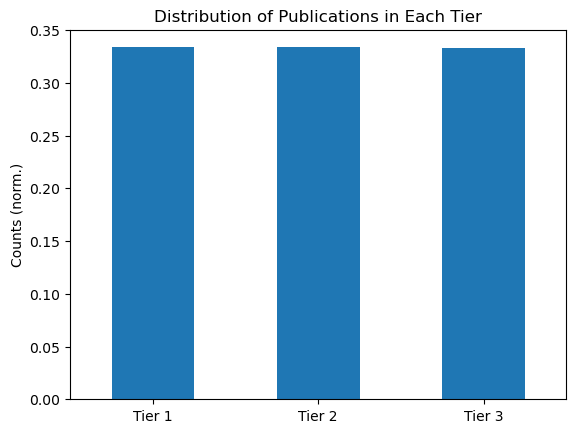

In [154]:
pub_df['PubTier'].value_counts(normalize = True).plot(kind = 'bar')
plt.title('Distribution of Publications in Each Tier')

plt.xticks(ticks = range(3), labels = [f'Tier {i+1}' for i in range(3)], rotation = 0)
plt.ylabel('Counts (norm.)')

We can join the `pub_df` with the `papers_df`

In [155]:
join_df = pd.merge(left = papers_df, right = pub_df, left_on = 'PubTitle', right_on = 'PubTitle')

In [156]:
join_df.shape[0] == papers_df.shape[0]

True

In [157]:
join_df.head(3)

,first_auth,second_auth,third_auth,Cites,ManuscriptTitle,Year,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,query_author,PubTitle,PubType,SJR,H index,Country,Region,PubTier
0,d shi,valerio adinolfi,r comin,4186,low trapstate density and long carrier diffusi...,2015,523.000,523.0,8,0,edward sargent,science,journal,14.589,1229.0,United States,Northern America,1
1,h tan,a jain,oleksandr voznyy,1951,efficient and stable solutionprocessed planar ...,2017,325.250,279.0,7,0,edward sargent,science,journal,14.589,1229.0,United States,Northern America,1
2,b zhang,x zheng,oleksandr voznyy,1756,homogeneously dispersed multimetal oxygenevolv...,2016,250.875,251.0,7,0,edward sargent,science,journal,14.589,1229.0,United States,Northern America,1


In [158]:
tier_ser = join_df.groupby('PubTier')['H index'].apply(list)

In [159]:
# 1. Find Max

max_len = 0
for i in range(3):
    if len(tier_ser.values[i]) > max_len:
        max_len = len(tier_ser.values[i])

# 2. Initiate the NumPy array
h_arr = np.zeros([max_len, 3])
h_arr[:,:] = np.nan

# 3. Generate DataFrame
for i in range(3):
    h_arr[:len(tier_ser.values[i]), i] = np.asarray([int(j) for j in tier_ser.values[i]])

tier_df = pd.DataFrame(h_arr, columns = [f'Tier {i + 1}' for i in range(3)])

In [160]:
tier_df

,Tier 1,Tier 2,Tier 3
0,1229.0,84.0,42.0
1,1229.0,84.0,42.0
2,1229.0,84.0,42.0
3,1229.0,84.0,42.0
4,1229.0,84.0,42.0
...,...,...,...
12274,120.0,NaN,NaN
12275,120.0,NaN,NaN
12276,120.0,NaN,NaN
12277,397.0,NaN,NaN


Each entry `H index` is in the `tier_df`

In [161]:
join_df.shape[0] == tier_df.isna().count().sum() - tier_df.isna().sum().sum()

True

Text(0.5, 1.0, 'Distribution of Publictaion H Indexes for Each Tier')

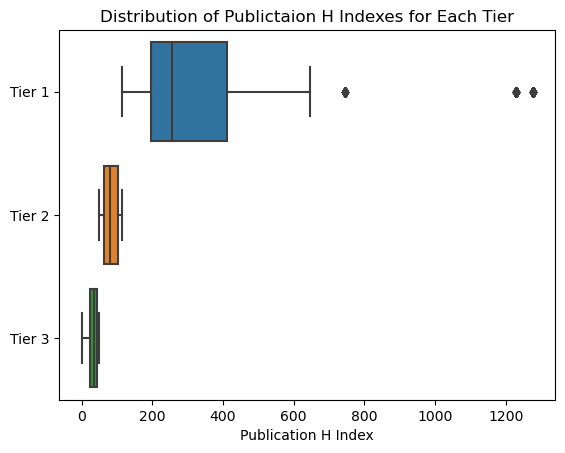

In [162]:
import seaborn as sns
sns.boxplot(data = tier_df, orient='h')
plt.xlabel('Publication H Index')
plt.title('Distribution of Publictaion H Indexes for Each Tier')

<AxesSubplot:>

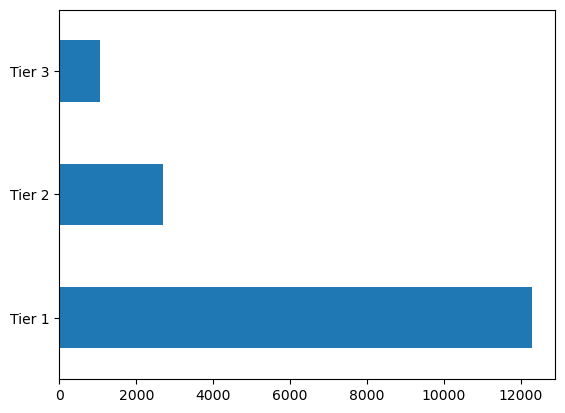

In [163]:
tier_df.count().plot(kind = 'barh')

In [164]:
join_df.to_pickle('2023-03-28_NB3_join_df_part3_method1.pkl')

Disproportinate amount of papers in the `Tier 1`. Need to sort the tiers based off of the number of observations, not journals.

### Method 2

In [165]:
sort_df = papers_df.sort_values(by = ['H index', 'PubTitle'], ascending=False)

In [166]:
paper_names = sort_df['PubTitle'].values

tier_member_max = int(sort_df.shape[0]/3)
pub_dic = {'PubTitle': [], 'PubTier': []}

counter = 0
tier = 1
for i in range(sort_df.shape[0]):
    
    if counter > tier_member_max and tier !=3 and paper_names[i] != paper_names[i-1]:
        
        tier = tier + 1
        counter = 0
    
    pub_dic['PubTitle'].append(paper_names[i])
    pub_dic['PubTier'].append(tier)
        
    counter = counter + 1

In [167]:
pub_df = pd.DataFrame(pub_dic)

Need to check if any journals are in more than one tier

In [168]:
uni_jour = [np.asarray(i) for i in pub_df.groupby('PubTier')['PubTitle'].unique().apply(list).values]
match_list = []

for i in range(len(uni_jour)):
    for j in range(i + 1, len(uni_jour)):
        element_arr = uni_jour[i]
        test_arr = uni_jour[j]
        for h in range(len(element_arr)):
            result = np.isin(element_arr[h], test_arr)
            if result == True:
                match_list.append(element_arr[h])

if len(match_list) == 0:
    print('No Matches')
else:
    print('Matches')

No Matches


In [169]:
pub_df = pd.DataFrame(pub_df.groupby('PubTitle')['PubTier'].mean().astype('int8')).reset_index()

In [170]:
join_df = pd.merge(left = papers_df, right = pub_df, left_on = 'PubTitle', right_on = 'PubTitle')

In [171]:
join_df.shape[0] == papers_df.shape[0]

True

In [172]:
tier_ser = join_df.groupby('PubTier')['H index'].apply(list)

# 1. Find Max
max_len = 0
for i in range(3):
    if len(tier_ser.values[i]) > max_len:
        max_len = len(tier_ser.values[i])

# 2. Initiate the NumPy array
h_arr = np.zeros([max_len, 3])
h_arr[:,:] = np.nan

# 3. Generate DataFrame
for i in range(3):
    h_arr[:len(tier_ser.values[i]), i] = np.asarray([int(j) for j in tier_ser.values[i]])

tier_df = pd.DataFrame(h_arr, columns = [f'Tier {i + 1}' for i in range(3)])

In [173]:
join_df.shape[0] == tier_df.isna().count().sum() - tier_df.isna().sum().sum()

True

Text(0.5, 1.0, 'Distribution of Publictaion H Indexes for Each Tier')

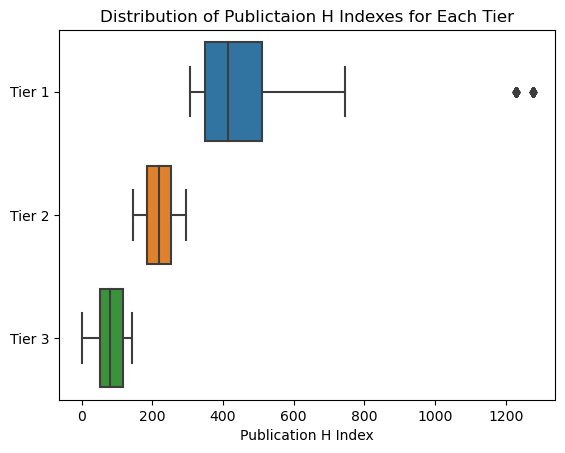

In [174]:
sns.boxplot(data = tier_df, orient='h')
plt.xlabel('Publication H Index')
plt.title('Distribution of Publictaion H Indexes for Each Tier')

Text(0.5, 0, 'Number of Observations in Each Tier')

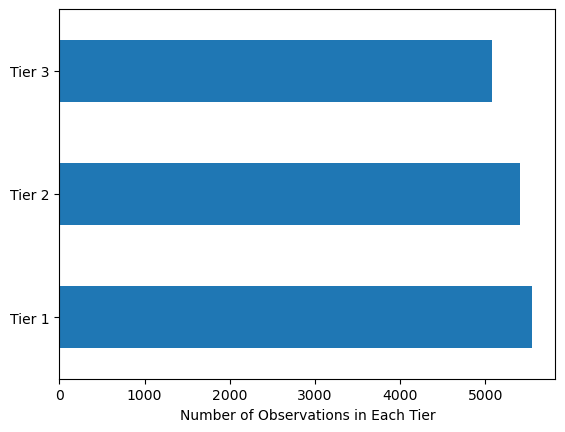

In [175]:
tier_df.count().plot(kind = 'barh')
plt.xlabel('Number of Observations in Each Tier')

Need to see the number of journals for each tier

In [176]:
vals = join_df.groupby(['PubTier'])['PubTitle'].apply(list).values

plt_keys = [f'Tier {i + 1}' for i in range(3)]
plt_dic = {}
for i in range(len(vals)):
    jour_cts = np.unique(vals[i]).shape[0]
    plt_dic[plt_keys[i]] = jour_cts

plt_ser = pd.Series(plt_dic)

Text(0.5, 0, 'Number of Journals in Each Tier')

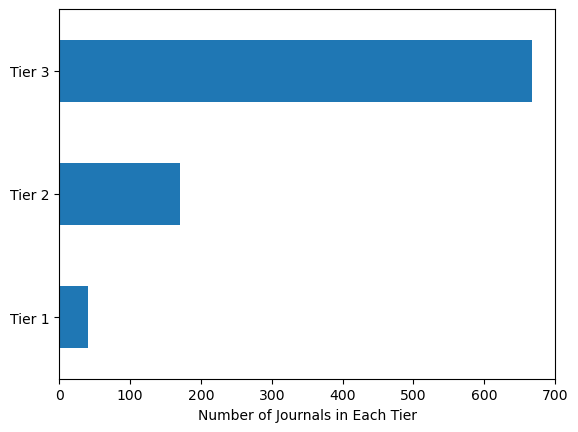

In [177]:
plt_ser.plot(kind = 'barh')
plt.xlabel('Number of Journals in Each Tier')

Therefore, most of obervations are of publictations that have published in `Tier 1`

In [178]:
join_df.to_pickle('2023-03-28_NB3_join_df_part3_method2.pkl')

In [180]:
papers_df = join_df.reset_index(drop = True)

In [181]:
papers_df.to_pickle('2023-03-28_NB3_papers_df_part3.pkl')

----